#=============================================
#LIBRARY MANAGEMENT SYSTEM
#Electronics & Telecommunication Engineering
#Batch:A-2
#Team Details:
##Ayush Dumbre ; PRN:25070123029
##Ayush Phale ; PRN:25070123028
##Bidisha Chaudhuri ; PRN:25070123034
#============================================

In [1]:
!pip install prettytable yagmail pandas matplotlib

# ========================
# CONFIGURATION
# ========================

In [2]:
# Import userdata to access Colab secrets
from google.colab import userdata
LIBRARIAN_EMAIL = 'librarian232@gmail.com'
EMAIL_PASSWORD = userdata.get('YAGMAIL_PASSWORD')
# CSV Files (will be created automatically if not exist)
LIBRARY_RECORDS_FILE = "/content/Library_records_500.csv"
LATE_SUBMISSION_FILE = "/content/LATE_submission_Records.csv"

# GLOBAL VARIABLE:
yag = None


#IMPORTING VARIOUS ESSENTIAL LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from datetime import datetime, timedelta
import yagmail

In [4]:
!pip install yagmail

# ========================
# UTILITY FUNCTIONS:
##Email Testing
##Loading Library & Late Records
##Saving Library & Late Records
# ========================


In [5]:
#Email Testing

def initialize_email():
    """Initialize yagmail SMTP connection using Colab Secrets"""
    global yag
    try:
        yag = yagmail.SMTP(LIBRARIAN_EMAIL, EMAIL_PASSWORD)
        print("Email system initialized!")

        return True
    except Exception as e:
        print(f"Email setup failed: {e}")
        print("Receipts will be displayed but not emailed.")
        return False

#Loading Library & Late Records

def load_library_records():
    """Load or create library records"""
    try:
        df = pd.read_csv(LIBRARY_RECORDS_FILE)
        df.columns = df.columns.str.strip()
        for col in ['unique id', 'phone no.', 'book serial no.']:
            if col in df.columns:
                df[col] = df[col].astype(str)
        return df
    except:
        # Create empty dataframe with correct columns
        columns = ['unique id', 'name', 'year of study', 'department', 'book serial no.',
                   'book name', 'date of issue', 'submit date', 'phone no.', 'email id']
        return pd.DataFrame(columns=columns)

def load_late_records():
    """Load or create late submission records"""
    try:
        df = pd.read_csv(LATE_SUBMISSION_FILE)
        df.columns = df.columns.str.strip()
        return df
    except:
        columns = ['unique id', 'name', 'year of study', 'department', 'book serieal no.',
                   'book name', 'submit date', 'email id', 'Net Charges']
        return pd.DataFrame(columns=columns)

#Saving Library & Late Records

def save_library_records(df):
    """Save library records"""
    try:
        df.to_csv(LIBRARY_RECORDS_FILE, index=False)
        return True
    except Exception as e:
        print(f" Save failed: {e}")
        return False

def save_late_records(df):
    """Save late records"""
    try:
        df.to_csv(LATE_SUBMISSION_FILE, index=False)
        return True
    except Exception as e:
        print(f" Save failed: {e}")
        return False


# Defining functions to make & mail the receipt

In [6]:
def send_email_receipt(recipient_email, subject, receipt_text):
    """Send receipt email"""
    global yag
    if yag is None:
        print("Email not initialized")
        return False

    try:
        yag.send(to=recipient_email, subject=subject, contents=receipt_text)
        print(f"Receipt emailed to {recipient_email}")
        return True
    except Exception as e:
        print(f"Email failed: {e}")
        return False

def format_receipt(data, receipt_type="ISSUE"):
    """Exact receipt format as specified"""
    receipt = f"""
Name:                {data['name']}
Unique ID:           {data['unique_id']}
Book Serial No.:     {data['book_serial']}
Book Name:           {data['book_name']}
Date of Issue:       {data['date_of_issue']}
Date of Submission:  {data['submit_date']}
"""

    if receipt_type == "LATE FEE":
        receipt += f"Late Fee:            {data['late_fee']} INR\n"

    receipt += f"""

1) Late fees which are progressive in nature will be charged on failure of returning book on time.
2) No excuses are entertained.
"""
    return receipt

Email system initialized!
System Ready!


    LIBRARY MANAGEMENT SYSTEM
1.  Issue Book
2.  Submit / Return Book
3.  View Book Submission Expiry Dates
4.  Search Student or Book
5.  View Late Submission Records
6.  Generate & Email Late Fee Receipt
7. Analytics – Most Issued Books
8. Exit

Choice: 1

               ISSUE BOOK
Unique ID: STU1004
Name: Karan Nair
Year of Study: 3
Department: Mechanical Engineering
Phone: 9973599262
Email: karan.nair75@university.edu
Book Serial No.: BK-99999
Book Name: The Alchemist
Days allowed (default 14): 14


/tmp/ipykernel_22384/2304943810.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[idx, key] = value



Issue Date: 2026-04-19
Submit By: 2026-05-03
Student record updated

RECEIPT:

Name:                Karan Nair
Unique ID:           STU1004
Book Serial No.:     BK-99999
Book Name:           The Alchemist
Date of Issue:       2026-04-19
Date of Submission:  2026-05-03


1) Late fees which are progressive in nature will be charged on failure of returning book on time.
2) No excuses are entertained.


Email receipt? (yes/no): YES
Receipt emailed to karan.nair75@university.edu

Press Enter...

    LIBRARY MANAGEMENT SYSTEM
1.  Issue Book
2.  Submit / Return Book
3.  View Book Submission Expiry Dates
4.  Search Student or Book
5.  View Late Submission Records
6.  Generate & Email Late Fee Receipt
7. Analytics – Most Issued Books
8. Exit

Choice: 1

               ISSUE BOOK
Unique ID: STU1501
Name: Ayush Dumbre
Year of Study: 2
Department: Computer Science 
Phone: 9876543210
Email: ayushdumbre2w2@gmail.com
Book Serial No.:  BK-69868
Book Name: The Alchemist
Days allowed (default 14): 16



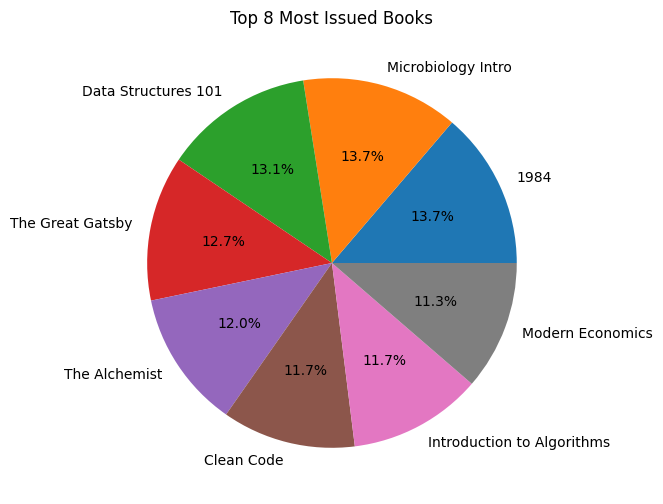


TOP 8 BOOKS:
+------+----------------------------+-------+
| Rank |         Book Name          | Count |
+------+----------------------------+-------+
|  1   |            1984            |   40  |
|  2   |     Microbiology Intro     |   40  |
|  3   |    Data Structures 101     |   38  |
|  4   |      The Great Gatsby      |   37  |
|  5   |       The Alchemist        |   35  |
|  6   |         Clean Code         |   34  |
|  7   | Introduction to Algorithms |   34  |
|  8   |      Modern Economics      |   33  |
+------+----------------------------+-------+


KeyboardInterrupt: Interrupted by user

In [7]:

# ========================
# OPTION 1: ISSUE BOOK (Merged - handles existing/new students)
# ========================

def issue_book():
    """Issue book - update if student exists, else add new"""
    print("\n" + "=" * 60)
    print("               ISSUE BOOK")
    print("=" * 60)

    df = load_library_records()

    # Student details
    unique_id = input("Unique ID: ").strip()
    name = input("Name: ").strip()
    year = input("Year of Study: ").strip()
    dept = input("Department: ").strip()
    phone = input("Phone: ").strip()
    email = input("Email: ").strip()

    # Book details
    book_serial = input("Book Serial No.: ").strip()
    book_name = input("Book Name: ").strip()

    # Dates
    issue_date = datetime.now().strftime('%Y-%m-%d')
    days_allowed = int(input("Days allowed (default 14): ") or 14)
    submit_date = (datetime.now() + timedelta(days=days_allowed)).strftime('%Y-%m-%d')

    print(f"\nIssue Date: {issue_date}")
    print(f"Submit By: {submit_date}")

    # Finding Student Record-
    student_exists = df[df['unique id'] == unique_id]

    # Create record
    record = {
        'unique id': unique_id, 'name': name, 'year of study': year,
        'department': dept, 'book serial no.': book_serial,
        'book name': book_name, 'date of issue': issue_date,
        'submit date': submit_date, 'phone no.': phone, 'email id': email
    }

    # Update or add new
    if not student_exists.empty:
        # Update existing row
        idx = student_exists.index[0]
        for key, value in record.items():
            df.at[idx, key] = value
        print("Student record updated")
    else:
        # Add new row
        df = pd.concat([df, pd.DataFrame([record])], ignore_index=True)
        print("New student record added")

    # Save and receipt
    if save_library_records(df):
        receipt_data = {
            'name': name, 'unique_id': unique_id, 'book_serial': book_serial,
            'book_name': book_name, 'date_of_issue': issue_date, 'submit_date': submit_date
        }
        receipt = format_receipt(receipt_data)
        print("\nRECEIPT:\n" + receipt)

        confirm = input("\nEmail receipt? (yes/no): ").strip().lower()
        if confirm == 'yes':
            send_email_receipt(email, f"Library Receipt - {book_name}", receipt)

    input("\nPress Enter...")

# ========================
# OPTION 2: SUBMIT/RETURN BOOK
# ========================

def submit_book():
    """Process book return - FIXED INDEX (uses ROW# 0,1,2...)"""
    print("\n" + "=" * 60)
    print("           RETURN BOOK")
    print("=" * 60)

    df = load_library_records()
    late_df = load_late_records()

    if df.empty:
        print("No active books!")
        input("\nPress Enter...")
        return

    # Search
    print("\n Search by:")
    print("1 = Unique ID")
    print("2 = Book Serial No.")
    search_by = input("Enter 1 or 2: ").strip()

    if search_by == '1':
        search_val = input("Enter Unique ID: ").strip()
        records = df[df['unique id'] == search_val]
    else:
        search_val = input("Enter Book Serial No.: ").strip()
        records = df[df['book serial no.'] == search_val]

    if records.empty:
        print(" No matching records!")
        input("\nPress Enter...")
        return

    print("\n SELECT BOOK TO RETURN:")
    table = PrettyTable(['Row#', 'ID', 'Name', 'Book Serial', 'Book', 'Due Date'])

    for row_num, (idx, row) in enumerate(records.iterrows()):
        table.add_row([
            row_num,
            row['unique id'], row['name'][:12],
            row['book serial no.'][:8], row['book name'][:15],
            row['submit date']
        ])

    print(table)

    # Get ROW NUMBER (0,1,2...)
    try:
        row_num = int(input("\nEnter ROW# (0,1,2...): ").strip())

        if row_num < 0 or row_num >= len(records):
            print(" Invalid row number!")
            input("\nPress Enter...")
            return

        # Convert row to actual dataframe index
        record_idx = records.index[row_num]
        record = records.loc[record_idx]

        print(f"\nProcessing: {record['name']} - {record['book name']}")

        # Today's date
        actual_date = datetime.now().strftime('%Y-%m-%d')

        # Late fee calculation
        submit_dt = pd.to_datetime(record['submit date'])
        actual_dt = pd.to_datetime(actual_date)
        days_late = (actual_dt - submit_dt).days
        late_fee = max(0, days_late * 10)

        # Remove from library records
        df = df.drop(record_idx)
        save_library_records(df)

        if late_fee > 0:
            print(f"\n LATE BY {days_late} DAYS!")
            print(f" Late Fee: {late_fee} INR")

            # Add to late records
            late_record = {
                'unique id': record['unique id'],
                'name': record['name'],
                'year of study': record['year of study'],
                'department': record['department'],
                'book serieal no.': record['book serial no.'],
                'book name': record['book name'],
                'submit date': actual_date,
                'email id': record['email id'],
                'Net Charges': late_fee
            }
            late_df = pd.concat([late_df, pd.DataFrame([late_record])], ignore_index=True)
            save_late_records(late_df)

            # Late fee receipt
            receipt_data = {
                'name': record['name'],
                'unique_id': record['unique id'],
                'book_serial': record['book serial no.'],
                'book_name': record['book name'],
                'date_of_issue': record['date of issue'],
                'submit_date': actual_date,
                'late_fee': f"{late_fee} INR"
            }
            receipt = format_receipt(receipt_data, "LATE FEE")
            print("\n LATE FEE RECEIPT:\n" + receipt)

            email_confirm = input("\n Send email receipt? (y/n): ").strip().lower()
            if email_confirm == 'y':
                send_email_receipt(record['email id'], f"Late Fee {late_fee} INR - {record['book name']}", receipt)
        else:
            print("\n Returned ON TIME - No fees!")

        print("\nBook return completed!")

    except ValueError:
        print("Please enter a valid number!")

    input("\nPress Enter...")


# ========================
# OPTION 3: EXPIRY DATES
# ========================

def view_expiry():
    """View submission expiry dates"""
    print("\n" + "=" * 60)
    print("        EXPIRY DATES")
    print("=" * 60)

    df = load_library_records()
    if df.empty:
        print("No active books!")
        input("\nPress Enter...")
        return

    today = datetime.now()
    table_data = []

    for idx, row in df.iterrows():
        submit_dt = pd.to_datetime(row['submit date'])
        days_left = (submit_dt - today).days
        status = 'OVERDUE' if days_left < 0 else 'OK'
        table_data.append([row['name'], row['unique id'], row['book name'],
                           row['submit date'], days_left, status])

    table = PrettyTable(['Name', 'ID', 'Book', 'Due Date', 'Days Left', 'Status'])
    for row in table_data:
        table.add_row(row)
    print(table)

    overdue = len([r for r in table_data if r[4] < 0])
    print(f"\nOverdue: {overdue}")
    input("\nPress Enter...")

# ========================
# OPTION 4: SEARCH
# ========================

def search():
    """Search student or book"""
    print("\n" + "=" * 60)
    print("              SEARCH")
    print("=" * 60)

    df = load_library_records()
    if df.empty:
        print("No records!")
        input("\nPress Enter...")
        return

    print("1=ID 2=Name 3=Book Serial 4=Book Name")
    choice = input("Choice: ").strip()
    term = input("Search: ").strip()

    if choice == '1':
        results = df[df['unique id'].astype(str) == term]
    elif choice == '2':
        results = df[df['name'].str.contains(term, case=False, na=False)]
    elif choice == '3':
        results = df[df['book serial no.'] == term]
    elif choice == '4':
        results = df[df['book name'].str.contains(term, case=False, na=False)]
    else:
        results = pd.DataFrame()

    if results.empty:
        print("No results!")
    else:
        table = PrettyTable(['ID', 'Name', 'Book', 'Issue Date', 'Due Date'])
        for idx, row in results.iterrows():
            table.add_row([row['unique id'], row['name'], row['book name'],
                           row['date of issue'], row['submit date']])
        print(table)

    input("\nPress Enter...")

# ========================
# OPTION 5: LATE RECORDS
# ========================

def view_late_records():
    """View late submission records"""
    print("\n" + "=" * 60)
    print("         LATE RECORDS")
    print("=" * 60)

    df = load_late_records()
    if df.empty:
        print("No late records!")
        input("\nPress Enter...")
        return

    table = PrettyTable(['ID', 'Name', 'Book', 'Date', 'Fine(INR)'])
    total_fine = 0
    for idx, row in df.iterrows():
        fine = row['Net Charges']
        total_fine += fine
        table.add_row([row['unique id'], row['name'], row['book name'],
                       row['submit date'], f"{fine}"])
    print(table)
    print(f"Total Fine Collected: {total_fine} INR")
    input("\nPress Enter...")

# ========================
# OPTION 6: LATE FEE RECEIPT
# ========================

def late_fee_receipt():
    """Generate late fee receipt"""
    print("\n" + "=" * 60)
    print("       LATE FEE RECEIPT")
    print("=" * 60)

    df = load_late_records()
    if df.empty:
        print("No late records!")
        input("\nPress Enter...")
        return

    uid = input("Unique ID: ").strip()
    records = df[df['unique id'] == uid]

    if records.empty:
        print("No late records for this ID!")
        input("\nPress Enter...")
        return

    total_fine = records['Net Charges'].sum()
    name = records.iloc[0]['name']
    email = records.iloc[0]['email id']

    receipt = f"""
Name:                {name}
Unique ID:           {uid}
Total Late Fee:      {total_fine} INR

Late Records:
"""
    for idx, row in records.iterrows():
        receipt += f"Book: {row['book name']} - Fine: {row['Net Charges']} INR\n"

    receipt += """
1) Late fees which are progressive in nature will be charged on failure of returning book on time.
2) No excuses are entertained.
"""

    print("RECEIPT:\n" + receipt)

    confirm = input("\nEmail receipt? (yes/no): ").strip().lower()
    if confirm == 'yes':
        send_email_receipt(email, f"Late Fee Receipt - {total_fine} INR", receipt)

    input("\nPress Enter...")

# ========================
# OPTION 7: ANALYTICS
# ========================
# ANALYTICS - MOST ISSUED BOOKS
def analytics():
    df = load_library_records()
    if df.empty:
        print("No data!")
        input("\nPress Enter...")
        return

    # Pie chart
    book_counts = df['book name'].value_counts().head(8)
    plt.figure(figsize=(10,6))
    plt.pie(book_counts.values, labels=book_counts.index, autopct='%1.1f%%')
    plt.title('Top 8 Most Issued Books')
    plt.show()

    # Top 8 table
    print("\nTOP 8 BOOKS:")
    table = PrettyTable(['Rank', 'Book Name', 'Count'])
    for i, (book, count) in enumerate(book_counts.items(), 1):
        table.add_row([i, book[:30], count])
    print(table)

    input("\nPress Enter...")

# ========================
# MAIN MENU
# ========================
def main_menu():
    print("\n" + "=" * 60)
    print("    LIBRARY MANAGEMENT SYSTEM")
    print("=" * 60)
    print("1.  Issue Book")
    print("2.  Submit / Return Book")
    print("3.  View Book Submission Expiry Dates")
    print("4.  Search Student or Book")
    print("5.  View Late Submission Records")
    print("6.  Generate & Email Late Fee Receipt")
    print("7. Analytics – Most Issued Books")
    print("8. Exit")

    return input("\nChoice: ").strip()

# ========================
# MAIN PROGRAM
# ========================
# Initialize
initialize_email()
print("System Ready!\n")

while True:
    choice = main_menu()
    if choice == '1':
        issue_book()
    elif choice == '2':
        submit_book()
    elif choice == '3':
        view_expiry()
    elif choice == '4':
        search()
    elif choice == '5':
        view_late_records()
    elif choice == '6':
        late_fee_receipt()
    elif choice == '7':
        analytics()
    elif choice == '8':
        print("Thank you!")
        break
    else:
        print(" Invalid choice!")
        input("Press Enter...")

#---------------------------------------------------------------------------

#Experiment 10
##Create-dataset-and-load-dataset-using-panda




In [8]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/Library_records_500.csv")
df


,unique id,name,year of study,department,book serial no.,book name,date of issue,submit date,phone no.,email id
0,STU1001,Vikram Das,3,Mathematics,BK-69868,The Alchemist,2026-10-10,2026-10-29,9192009434,vikram.das93@university.edu
1,STU1002,Kabir Patel,1,Electrical Engineering,BK-26499,Calculus Early Transcendentals,2026-02-08,2026-02-17,7293165521,kabir.patel45@university.edu
2,STU1003,Pooja Gupta,4,Computer Science,BK-83443,1984,2026-06-05,2026-06-15,9421591928,pooja.gupta64@university.edu
3,STU1004,Karan Nair,3,Mechanical Engineering,BK-99999,The Alchemist,2026-04-19,2026-05-03,9973599262,karan.nair75@university.edu
4,STU1005,Riya Singh,4,Civil Engineering,BK-16027,The Alchemist,2026-10-21,2026-10-28,9599188852,riya.singh66@university.edu
...,...,...,...,...,...,...,...,...,...,...
495,STU1496,Amit Nair,2,Computer Science,BK-11394,The Art of War,2026-03-06,2026-03-24,7807886312,amit.nair53@university.edu
496,STU1497,Pooja Iyer,1,Mathematics,BK-63968,1984,2026-07-06,2026-07-19,9087958624,pooja.iyer86@university.edu
497,STU1498,Meera Nair,3,Electrical Engineering,BK-37853,Physics for Scientists,2026-08-01,2026-08-22,7025387114,meera.nair51@university.edu
498,STU1499,Kabir Verma,3,Electrical Engineering,BK-60045,The Alchemist,2026-07-30,2026-08-13,9439015003,kabir.verma60@university.edu


In [9]:


print("===== DATASET HEAD =====")
print(df.head())
print()

print("===== DATASET TAIL =====")
print(df.tail())
print()

print("===== DATASET INFO =====")
df.info()
print()

print("===== STATISTICAL SUMMARY =====")
print(df.describe())
print()

print("===== DATASET SHAPE =====")
print(df.shape)
print()

print("===== MISSING VALUES =====")
print(df.isnull().sum())
print()

# Add column
df["Status"] = "Submitted"
print("===== COLUMN ADDED =====")
print(df.head())
print()

# Drop column
df.drop("Status", axis=1, inplace=True)
print("===== COLUMN DROPPED =====")
print(df.head())
print()

# Sorting
print("===== SORTED DATA =====")
print(df.sort_values(by=df.columns[-1], ascending=False))
print()

# Save dataset
df.to_csv("processed_data.csv", index=False)

===== DATASET HEAD =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das              3             Mathematics   
1   STU1002  Kabir Patel              1  Electrical Engineering   
2   STU1003  Pooja Gupta              4        Computer Science   
3   STU1004   Karan Nair              3  Mechanical Engineering   
4   STU1005   Riya Singh              4       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

    phone no.                      email id  
0  9192009434   vikram.das93@university.edu  
1  72

In [10]:
# Fill numeric missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical missing values with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled")

Missing values handled


/tmp/ipykernel_22384/324399785.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
# Replace 'Book' with your actual column name (like 'Book_Name' or 'Title')

top_books = df['book name'].value_counts().head(10)

print("===== TOP 10 BOOKS READ =====")
print(top_books)
print()

===== TOP 10 BOOKS READ =====
book name
1984                          40
Microbiology Intro            40
Data Structures 101           38
The Great Gatsby              37
The Alchemist                 35
Clean Code                    34
Introduction to Algorithms    34
Modern Economics              33
Brave New World               33
Physics for Scientists        32
Name: count, dtype: int64



#Experiment 11
##Categorical-Data-Analaysis-using-Python





In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:

# Load dataset
df = pd.read_csv("/content/Library_records_500.csv")

print("===== DATASET HEAD =====")
print(df.head())
print()

print("===== DATASET TAIL =====")
print(df.tail())
print()

print("===== DATASET INFO =====")
df.info()
print()

print("===== STATISTICAL SUMMARY =====")
print(df.describe(include='all'))
print()

print("===== DATASET SHAPE =====")
print(df.shape)
print()

print("===== MISSING VALUES =====")
print(df.isnull().sum())
print()

print("===== UNIQUE VALUES =====")
print(df.nunique())
print()

# Save dataset
df.to_csv("processed_data.csv", index=False)

===== DATASET HEAD =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das              3             Mathematics   
1   STU1002  Kabir Patel              1  Electrical Engineering   
2   STU1003  Pooja Gupta              4        Computer Science   
3   STU1004   Karan Nair              3  Mechanical Engineering   
4   STU1005   Riya Singh              4       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

    phone no.                      email id  
0  9192009434   vikram.das93@university.edu  
1  72

In [14]:
categorical_cols = df.select_dtypes(include='object').columns

print("===== CATEGORICAL COLUMNS =====")
print(categorical_cols)
print()

===== CATEGORICAL COLUMNS =====
Index(['unique id', 'name', 'department', 'book serial no.', 'book name',
       'date of issue', 'submit date', 'email id'],
      dtype='object')



In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("===== LABEL ENCODED DATA =====")
print(df.head())
print()

===== LABEL ENCODED DATA =====
   unique id  name  year of study  department  book serial no.  book name  \
0          0   228              3           5              335         11   
1          1    68              1           3              109          2   
2          2   116              4           1              409          0   
3          3    80              3           6              497         11   
4          4   161              4           0               42         11   

   date of issue  submit date   phone no.  email id  
0            214          225  9192009434       453  
1             41           36  7293165521       130  
2            127          127  9421591928       222  
3             91           92  9973599262       155  
4            222          224  9599188852       315  



In [16]:
df_encoded = pd.get_dummies(df, columns=categorical_cols)

print("===== ONE HOT ENCODED DATA =====")
print(df_encoded.head())
print()

===== ONE HOT ENCODED DATA =====
   year of study   phone no.  unique id_0  unique id_1  unique id_2  \
0              3  9192009434         True        False        False   
1              1  7293165521        False         True        False   
2              4  9421591928        False        False         True   
3              3  9973599262        False        False        False   
4              4  9599188852        False        False        False   

   unique id_3  unique id_4  unique id_5  unique id_6  unique id_7  ...  \
0        False        False        False        False        False  ...   
1        False        False        False        False        False  ...   
2        False        False        False        False        False  ...   
3         True        False        False        False        False  ...   
4        False         True        False        False        False  ...   

   email id_486  email id_487  email id_488  email id_489  email id_490  \
0         Fals

In [17]:
col = categorical_cols[0]

filtered_df = df[df[col] == df[col].unique()[0]]

print(f"===== FILTERED DATA ({col}) =====")
print(filtered_df)
print()

===== FILTERED DATA (unique id) =====
   unique id  name  year of study  department  book serial no.  book name  \
0          0   228              3           5              335         11   

   date of issue  submit date   phone no.  email id  
0            214          225  9192009434       453  



#Experiment 12
##To perform preprocessing on dataset & dealing with Missing Values

In [18]:
# Load dataset
df = pd.read_csv("/content/Library_records_500.csv")

print("===== DATASET HEAD =====")
print(df.head())
print()

print("===== DATASET INFO =====")
df.info()
print()

print("===== DATASET SHAPE =====")
print(df.shape)
print()

print("===== MISSING VALUES =====")
print(df.isnull().sum())
print()

print("===== STATISTICAL SUMMARY =====")
print(df.describe(include='all'))
print()

===== DATASET HEAD =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das              3             Mathematics   
1   STU1002  Kabir Patel              1  Electrical Engineering   
2   STU1003  Pooja Gupta              4        Computer Science   
3   STU1004   Karan Nair              3  Mechanical Engineering   
4   STU1005   Riya Singh              4       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

    phone no.                      email id  
0  9192009434   vikram.das93@university.edu  
1  72

In [19]:
missing = df.isnull().sum()

print("===== MISSING VALUES COUNT =====")
print(missing)
print()

print("===== MISSING VALUES PERCENTAGE =====")
print((missing / len(df)) * 100)
print()

===== MISSING VALUES COUNT =====
unique id          0
name               0
year of study      0
department         0
book serial no.    0
book name          0
date of issue      0
submit date        0
phone no.          0
email id           0
dtype: int64

===== MISSING VALUES PERCENTAGE =====
unique id          0.0
name               0.0
year of study      0.0
department         0.0
book serial no.    0.0
book name          0.0
date of issue      0.0
submit date        0.0
phone no.          0.0
email id           0.0
dtype: float64



In [20]:
df_dropped = df.dropna()

print("===== DATA AFTER DROPPING MISSING VALUES =====")
print(df_dropped.head())
print()

===== DATA AFTER DROPPING MISSING VALUES =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das              3             Mathematics   
1   STU1002  Kabir Patel              1  Electrical Engineering   
2   STU1003  Pooja Gupta              4        Computer Science   
3   STU1004   Karan Nair              3  Mechanical Engineering   
4   STU1005   Riya Singh              4       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

    phone no.                      email id  
0  9192009434   vikram.das93@

In [21]:
# Fill numeric with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

print("===== MISSING VALUES AFTER FILLING =====")
print(df.isnull().sum())
print()


===== MISSING VALUES AFTER FILLING =====
unique id          0
name               0
year of study      0
department         0
book serial no.    0
book name          0
date of issue      0
submit date        0
phone no.          0
email id           0
dtype: int64



/tmp/ipykernel_22384/1486517686.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("===== NORMALIZED DATA =====")
print(df.head())
print()

===== NORMALIZED DATA =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.666667             Mathematics   
1   STU1002  Kabir Patel       0.000000  Electrical Engineering   
2   STU1003  Pooja Gupta       1.000000        Computer Science   
3   STU1004   Karan Nair       0.666667  Mechanical Engineering   
4   STU1005   Riya Singh       1.000000       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.732370   vikram.das93@university.edu  
1   

In [23]:
df.drop_duplicates(inplace=True)

print("===== DATA AFTER REMOVING DUPLICATES =====")
print(df.head())
print()

===== DATA AFTER REMOVING DUPLICATES =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.666667             Mathematics   
1   STU1002  Kabir Patel       0.000000  Electrical Engineering   
2   STU1003  Pooja Gupta       1.000000        Computer Science   
3   STU1004   Karan Nair       0.666667  Mechanical Engineering   
4   STU1005   Riya Singh       1.000000       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.732370   vikram.das93@univer

#Experiment 13
##Data-Binning-Data-Formatting-using-Python

In [24]:
# Load dataset
df = pd.read_csv("/content/Library_records_500.csv")

print("===== DATASET HEAD =====")
print(df.head())
print()

print("===== DATASET INFO =====")
df.info()
print()

print("===== DATASET SHAPE =====")
print(df.shape)
print()

print("===== STATISTICAL SUMMARY =====")
print(df.describe())
print()

===== DATASET HEAD =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das              3             Mathematics   
1   STU1002  Kabir Patel              1  Electrical Engineering   
2   STU1003  Pooja Gupta              4        Computer Science   
3   STU1004   Karan Nair              3  Mechanical Engineering   
4   STU1005   Riya Singh              4       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

    phone no.                      email id  
0  9192009434   vikram.das93@university.edu  
1  72

In [25]:
# Replace column names if needed
book_col = 'book name'
dept_col = 'department'

# Get top 10 books
top_books = df[book_col].value_counts().head(10).index

# Filter dataset for only top 10 books
filtered_df = df[df[book_col].isin(top_books)]

# Create pivot table (Department vs Book Count)
pivot_df = filtered_df.pivot_table(index=dept_col, columns=book_col, aggfunc='size', fill_value=0)

print("===== PIVOT TABLE =====")
print(pivot_df)
print()

===== PIVOT TABLE =====
book name               1984  Brave New World  Clean Code  \
department                                                  
Civil Engineering          8                3           8   
Computer Science           7                2           1   
Economics                 10                5          10   
Electrical Engineering     1                4           2   
Literature                 4                4           2   
Mathematics                4                6           3   
Mechanical Engineering     2                5           5   
Physics                    4                4           3   

book name               Data Structures 101  Introduction to Algorithms  \
department                                                                
Civil Engineering                         5                           3   
Computer Science                          8                           4   
Economics                                 4                      

In [26]:
import matplotlib.pyplot as plt

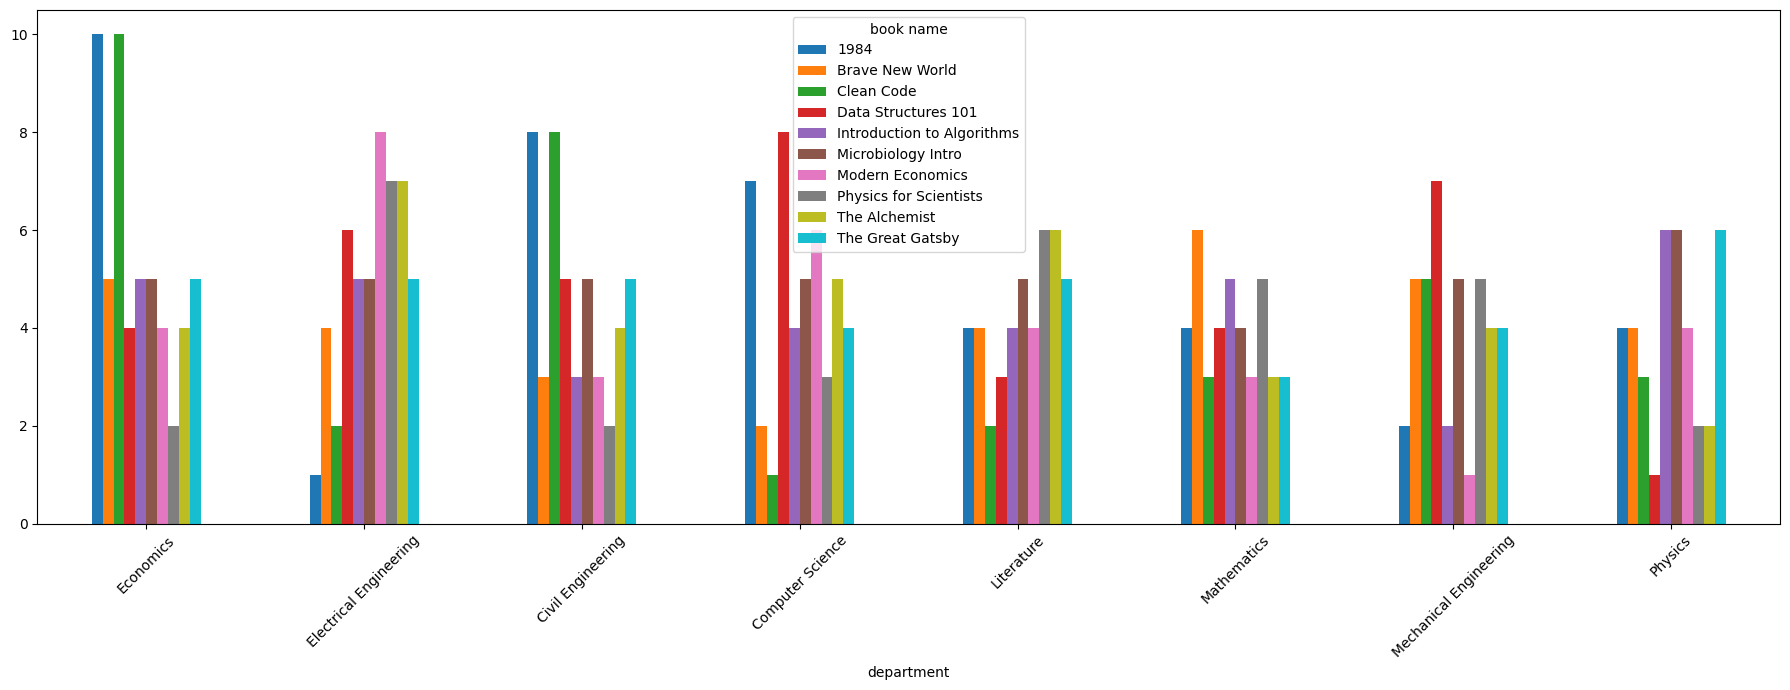

In [27]:
top_depts = pivot_df.sum(axis=1).sort_values(ascending=False).head(8).index
pivot_df_small = pivot_df.loc[top_depts]

pivot_df_small.plot(kind='bar', figsize=(18,7))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print()


===== LINE PLOT =====


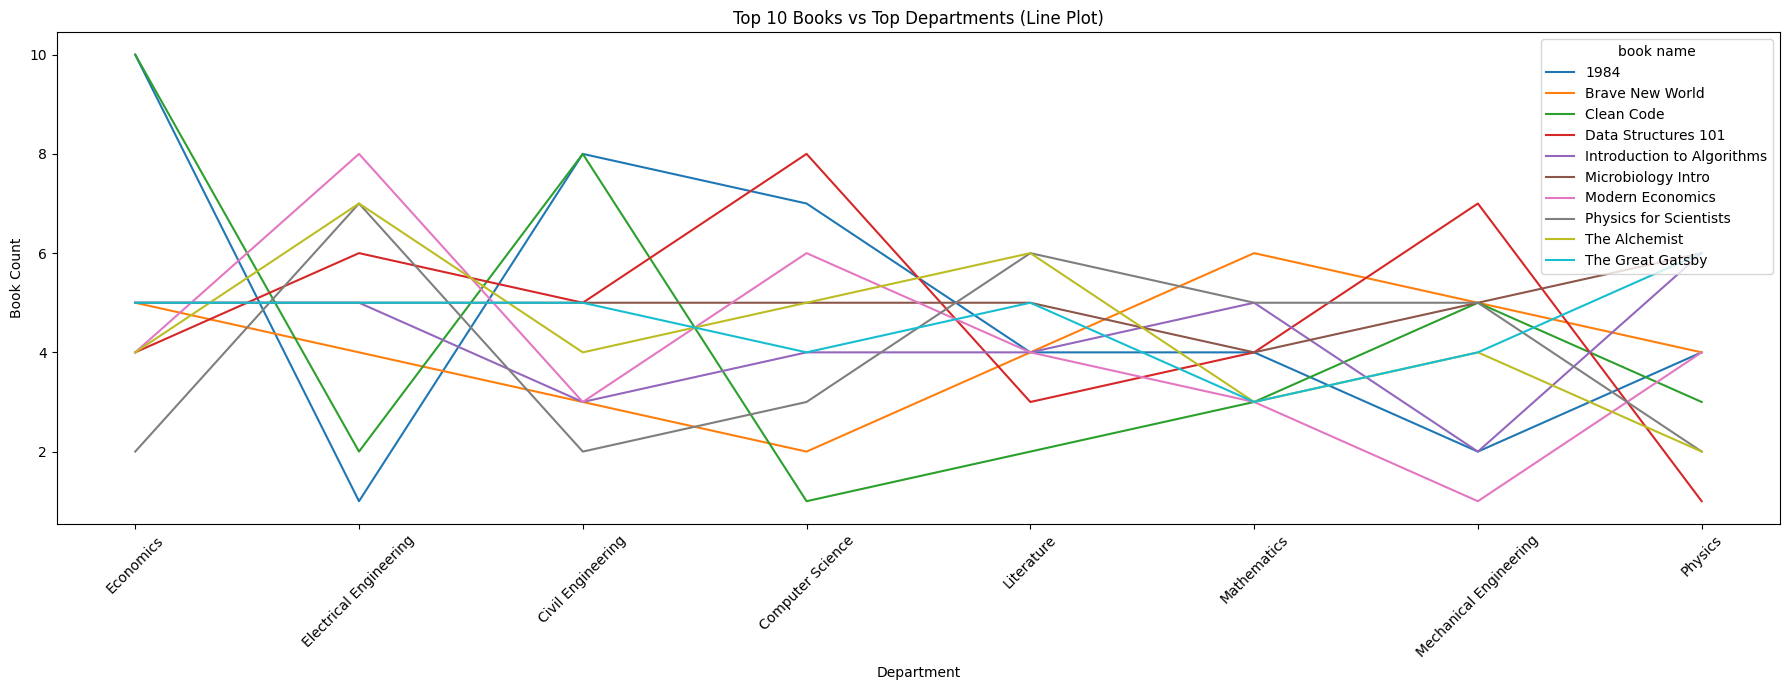

In [28]:

pivot_df_small.plot(figsize=(18,7))

import matplotlib.pyplot as plt
print("===== LINE PLOT =====")
plt.xlabel("Department")
plt.ylabel("Book Count")
plt.title("Top 10 Books vs Top Departments (Line Plot)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print()

===== BAR GRAPH =====


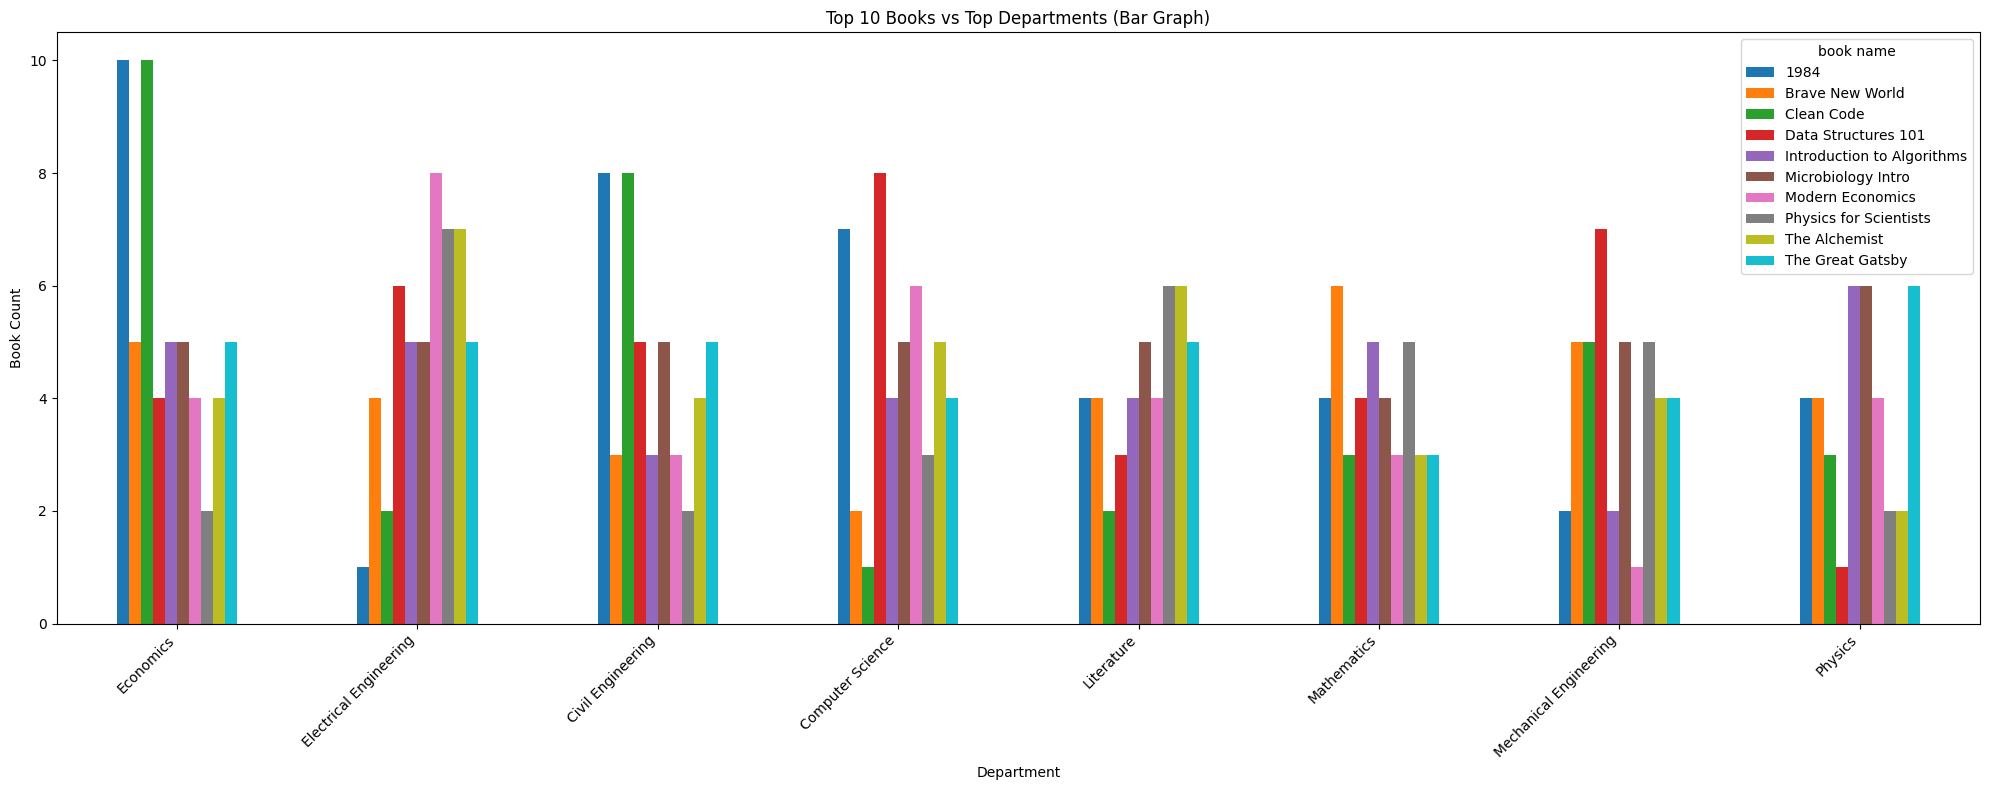

In [29]:
pivot_df_small.plot(kind='bar', figsize=(20,8))

print("===== BAR GRAPH =====")
plt.xlabel("Department")
plt.ylabel("Book Count")
plt.title("Top 10 Books vs Top Departments (Bar Graph)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print()

===== HISTOGRAM =====


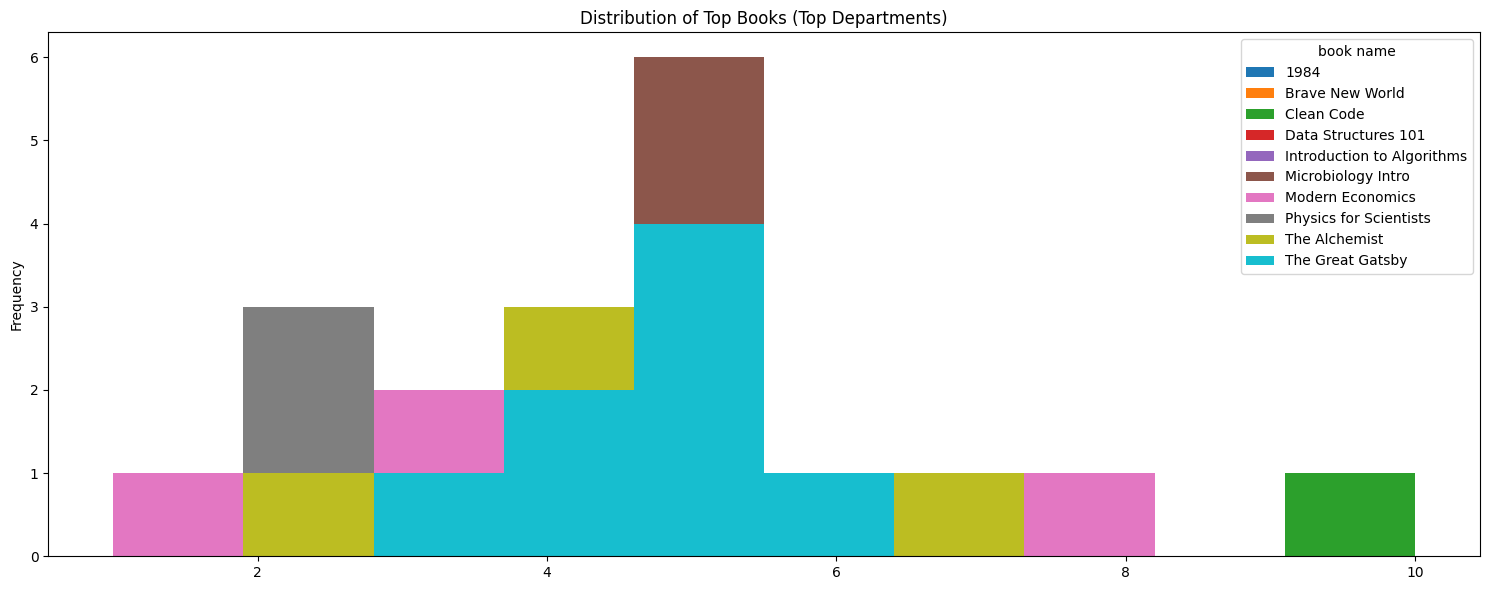

In [30]:
pivot_df_small.plot(kind='hist', figsize=(15,6))

print("===== HISTOGRAM =====")
plt.title("Distribution of Top Books (Top Departments)")
plt.tight_layout()
plt.show()
print()

===== SCATTER PLOT =====


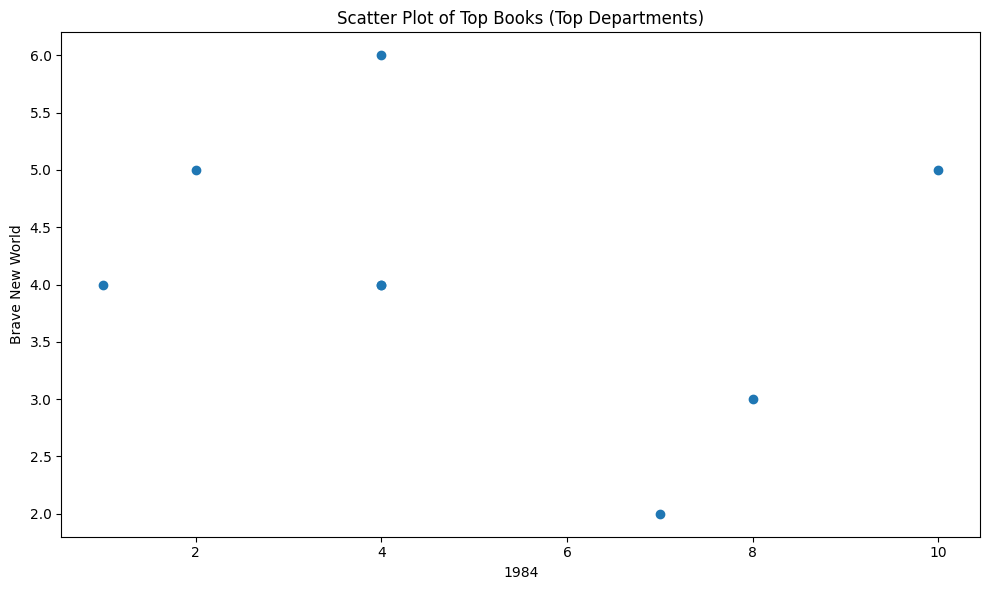

In [31]:
cols = pivot_df_small.columns

if len(cols) >= 2:
    plt.figure(figsize=(10,6))
    plt.scatter(pivot_df_small[cols[0]], pivot_df_small[cols[1]])

    print("===== SCATTER PLOT =====")
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.title("Scatter Plot of Top Books (Top Departments)")
    plt.tight_layout()
    plt.show()
    print()

===== PIE CHART =====


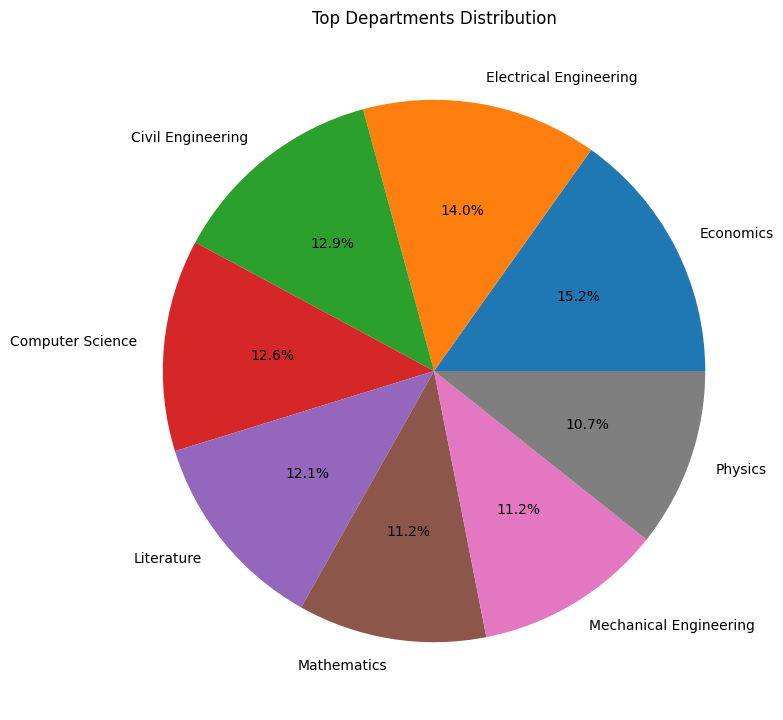

In [32]:
dept_totals = pivot_df_small.sum(axis=1)

plt.figure(figsize=(8,8))

print("===== PIE CHART =====")
dept_totals.plot.pie(autopct='%1.1f%%')

plt.title("Top Departments Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()
print()

#Experiment 14
##Data Normalization & Data Type Conversion

In [33]:
#MIN-MAX on "Years of study"
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("===== MIN-MAX NORMALIZED DATA =====")
print(df.head())
print()

===== MIN-MAX NORMALIZED DATA =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.666667             Mathematics   
1   STU1002  Kabir Patel       0.000000  Electrical Engineering   
2   STU1003  Pooja Gupta       1.000000        Computer Science   
3   STU1004   Karan Nair       0.666667  Mechanical Engineering   
4   STU1005   Riya Singh       1.000000       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.732370   vikram.das93@university.ed

In [34]:
#STANDARDIZATION (Z-SCORE)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("===== STANDARDIZED DATA =====")
print(df.head())
print()

===== STANDARDIZED DATA =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.425998             Mathematics   
1   STU1002  Kabir Patel      -1.348994  Electrical Engineering   
2   STU1003  Pooja Gupta       1.313494        Computer Science   
3   STU1004   Karan Nair       0.425998  Mechanical Engineering   
4   STU1005   Riya Singh       1.313494       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.811859   vikram.das93@university.edu  
1 

In [35]:
print("===== MIN VALUES =====")
print(df.min())
print()

print("===== MAX VALUES =====")
print(df.max())
print()

===== MIN VALUES =====
unique id                                 STU1001
name                                Aditya Chawla
year of study                           -1.348994
department                      Civil Engineering
book serial no.                          BK-10071
book name                                    1984
date of issue                          2025-12-11
submit date                            2026-01-01
phone no.                               -1.657653
email id           aditya.chawla89@university.edu
dtype: object

===== MAX VALUES =====
unique id                              STU1501
name                                Zoya Verma
year of study                         1.313494
department                             Physics
book serial no.                       BK-99999
book name                To Kill a Mockingbird
date of issue                       2026-12-22
submit date                         2026-12-31
phone no.                             1.714295
email id        

In [36]:
# Decimal Scaling: x' = x / (10^j)

numeric_cols = df.select_dtypes(include=np.number).columns

df_decimal = df.copy()

for col in numeric_cols:
    max_val = df[col].abs().max()

    j = 0
    while max_val >= 1:
        max_val = max_val / 10
        j += 1

    df_decimal[col] = df[col] / (10 ** j)

print("===== DECIMAL SCALING NORMALIZED DATA =====")
print(df_decimal.head())
print()


===== DECIMAL SCALING NORMALIZED DATA =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.042600             Mathematics   
1   STU1002  Kabir Patel      -0.134899  Electrical Engineering   
2   STU1003  Pooja Gupta       0.131349        Computer Science   
3   STU1004   Karan Nair       0.042600  Mechanical Engineering   
4   STU1005   Riya Singh       0.131349       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.081186   vikram.das93@unive

In [37]:
#NORMALIZE MULTIPLE COLUMNS
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Normalize multiple columns together
df_multi_norm = df.copy()
df_multi_norm[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("===== NORMALIZED MULTIPLE COLUMNS (MIN-MAX) =====")
print(df_multi_norm.head())
print()

===== NORMALIZED MULTIPLE COLUMNS (MIN-MAX) =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.666667             Mathematics   
1   STU1002  Kabir Patel       0.000000  Electrical Engineering   
2   STU1003  Pooja Gupta       1.000000        Computer Science   
3   STU1004   Karan Nair       0.666667  Mechanical Engineering   
4   STU1005   Riya Singh       1.000000       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.732370   vikram.das93

In [38]:
#STANDARDIZED MULTIPLE COLUMNS
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_std = df.copy()
df_std[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("===== STANDARDIZED MULTIPLE COLUMNS =====")
print(df_std.head())
print()

===== STANDARDIZED MULTIPLE COLUMNS =====
  unique id         name  year of study              department  \
0   STU1001   Vikram Das       0.425998             Mathematics   
1   STU1002  Kabir Patel      -1.348994  Electrical Engineering   
2   STU1003  Pooja Gupta       1.313494        Computer Science   
3   STU1004   Karan Nair       0.425998  Mechanical Engineering   
4   STU1005   Riya Singh       1.313494       Civil Engineering   

  book serial no.                       book name date of issue submit date  \
0        BK-69868                   The Alchemist    2026-10-10  2026-10-29   
1        BK-26499  Calculus Early Transcendentals    2026-02-08  2026-02-17   
2        BK-83443                            1984    2026-06-05  2026-06-15   
3        BK-99999                   The Alchemist    2026-04-19  2026-05-03   
4        BK-16027                   The Alchemist    2026-10-21  2026-10-28   

   phone no.                      email id  
0   0.811859   vikram.das93@univers

#Experiment 16

===== BAR CHART (TOP BOOKS) =====


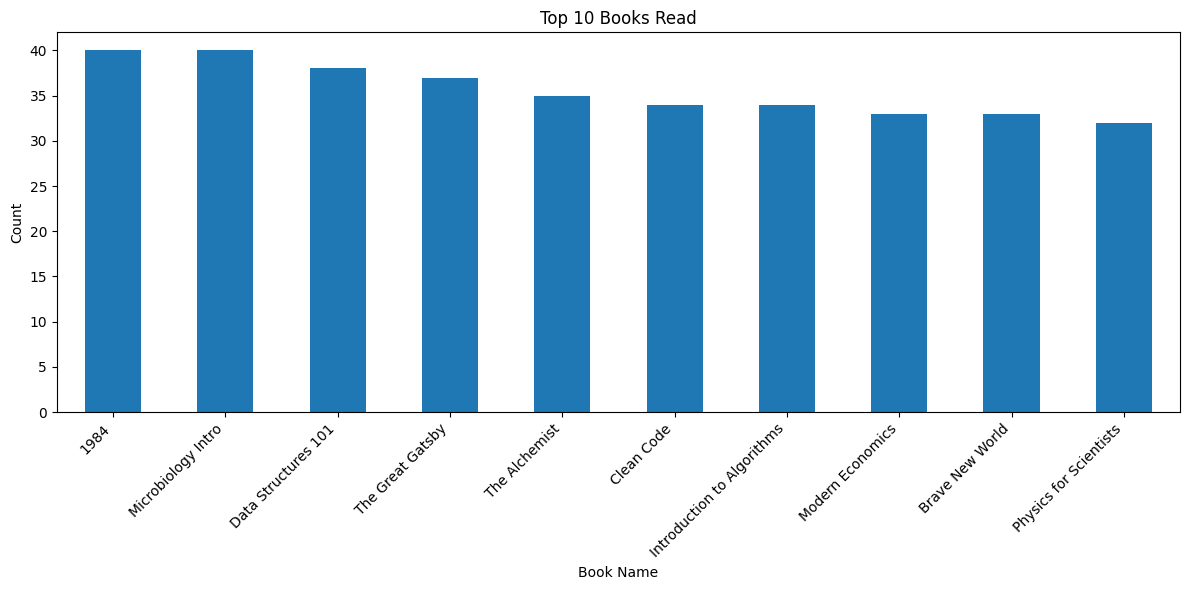

In [39]:
#BAR CHART: BOOK COUNT
book_counts = df['book name'].value_counts().head(10)

book_counts.plot(kind='bar', figsize=(12,6))

print("===== BAR CHART (TOP BOOKS) =====")
plt.xlabel("Book Name")
plt.ylabel("Count")
plt.title("Top 10 Books Read")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print()

===== PIE CHART (BOOK DISTRIBUTION) =====


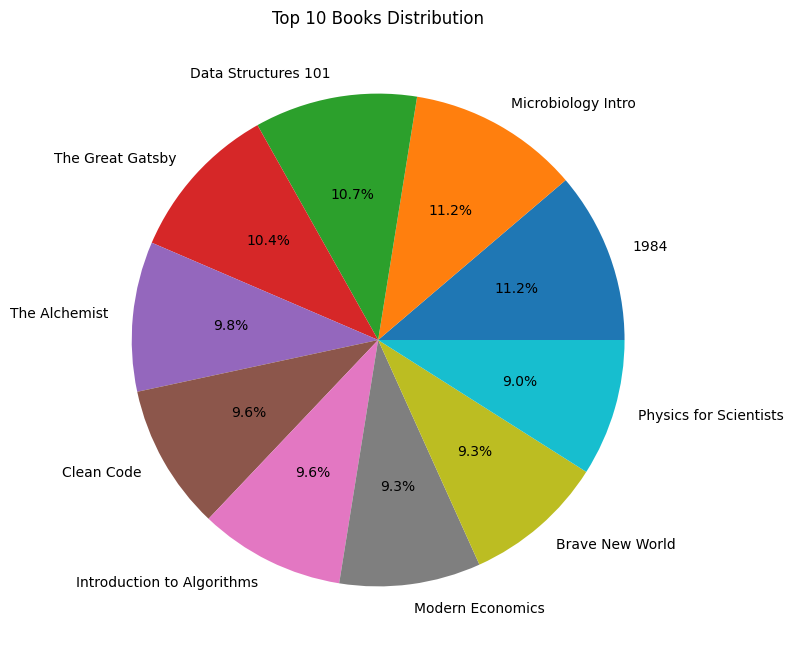

In [40]:
#PIE CHART: BOOK DISTRIBUTION
book_counts.plot.pie(autopct='%1.1f%%', figsize=(8,8))

print("===== PIE CHART (BOOK DISTRIBUTION) =====")
plt.title("Top 10 Books Distribution")
plt.ylabel("")
plt.show()
print()


===== BAR CHART (DEPARTMENTS) =====


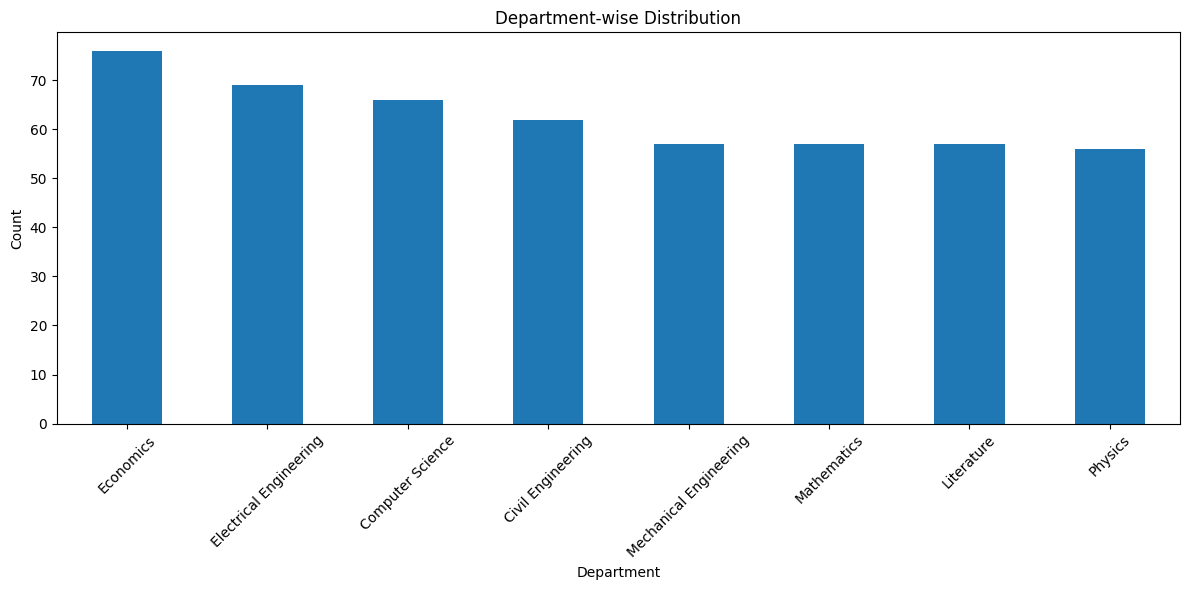

In [41]:
#BAR CHART: DEPARTMENT COUNT)
dept_counts = df['department'].value_counts()

dept_counts.plot(kind='bar', figsize=(12,6))

print("===== BAR CHART (DEPARTMENTS) =====")
plt.xlabel("Department")
plt.ylabel("Count")
plt.title("Department-wise Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print()

===== HISTOGRAM =====


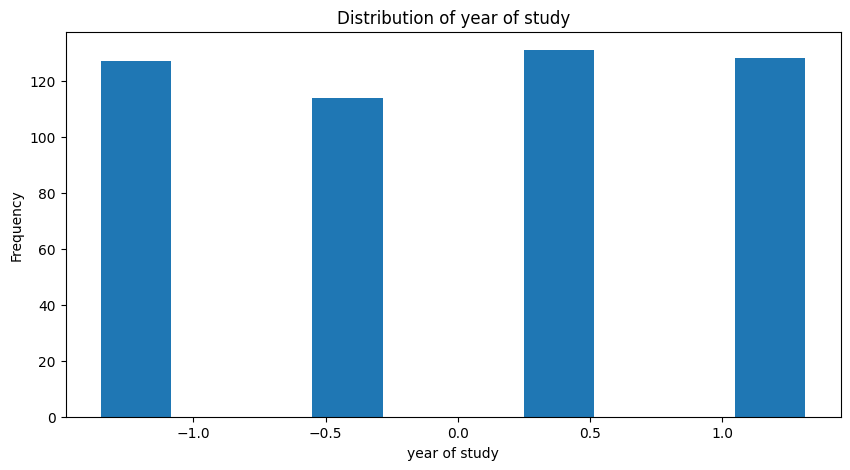

In [42]:
#HISTOGRAM: NUMERIC DATA
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    df[numeric_cols[0]].plot(kind='hist', figsize=(10,5))

    print("===== HISTOGRAM =====")
    plt.title(f"Distribution of {numeric_cols[0]}")
    plt.xlabel(numeric_cols[0])
    plt.ylabel("Frequency")
    plt.show()
    print()
else:
    print("No numeric column available\n")

===== SCATTER PLOT =====


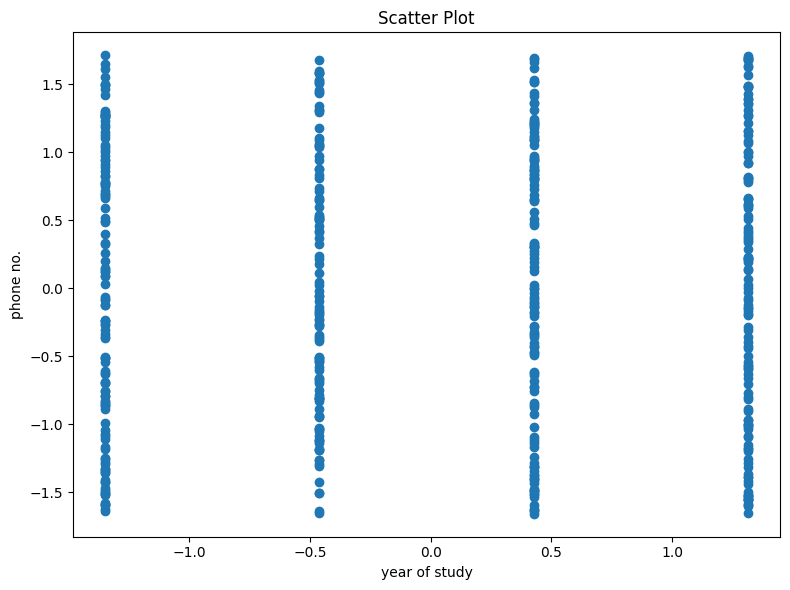

In [43]:
#Scatter PLot
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) >= 2:
    plt.figure(figsize=(8,6))
    plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]])

    print("===== SCATTER PLOT =====")
    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])
    plt.title("Scatter Plot")
    plt.tight_layout()
    plt.show()
    print()
else:
    print("Not enough numeric columns\n")

===== VISUAL ENCODING (COLOR BY BOOK) =====


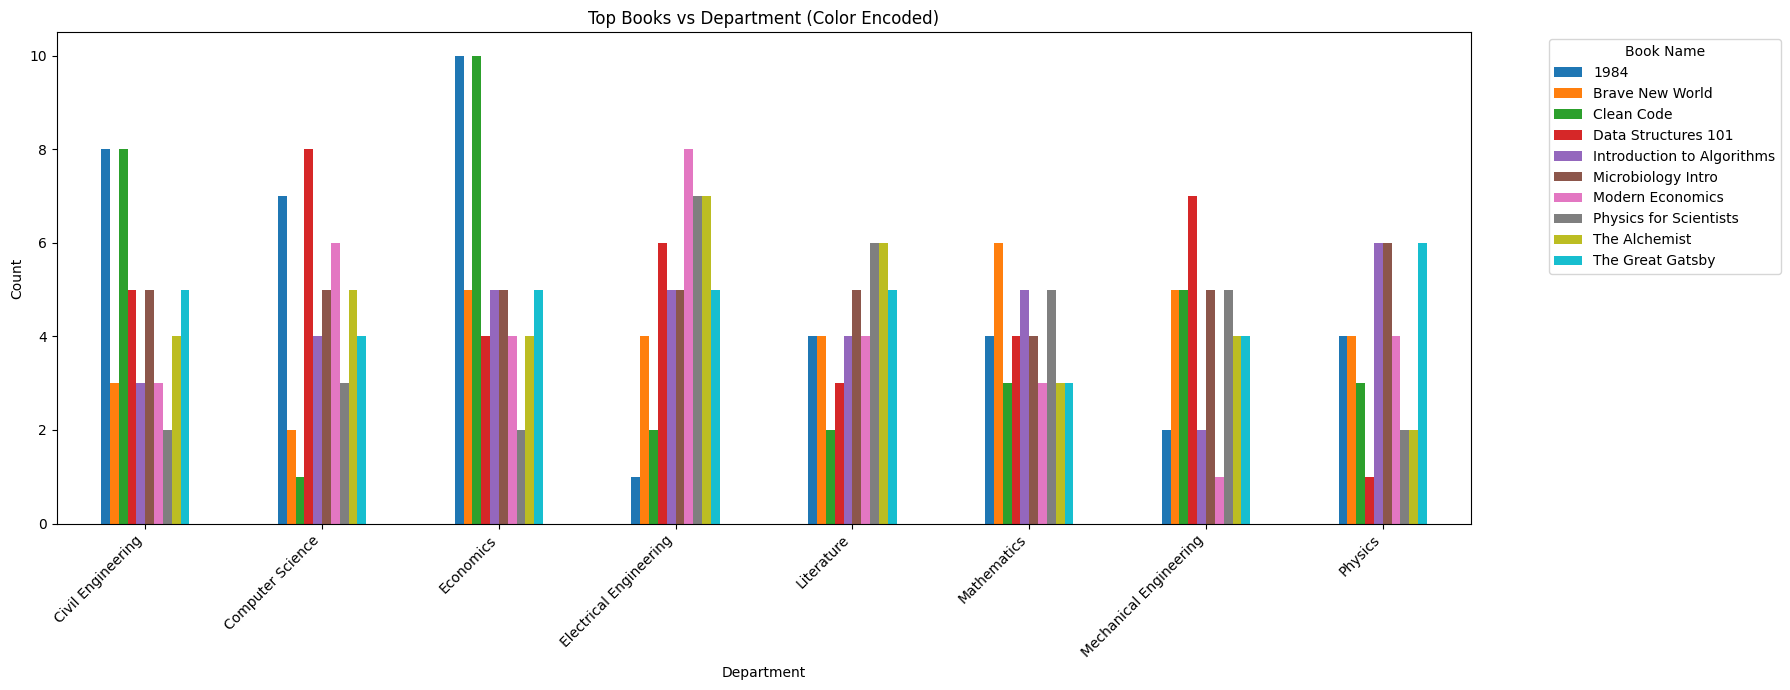

In [44]:
# Using color encoding based on Department

top_books = df['book name'].value_counts().head(10).index
filtered_df = df[df['book name'].isin(top_books)]

pivot_df = filtered_df.pivot_table(index='department', columns='book name', aggfunc='size', fill_value=0)

pivot_df.plot(kind='bar', figsize=(18,7))

print("===== VISUAL ENCODING (COLOR BY BOOK) =====")
plt.xlabel("Department")
plt.ylabel("Count")
plt.title("Top Books vs Department (Color Encoded)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Book Name", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()
print()

#Experiment 17

In [45]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("===== MEAN =====")
print(df[numeric_cols].mean())
print()

print("===== MEDIAN =====")
print(df[numeric_cols].median())
print()

print("===== MODE =====")
print(df.mode().iloc[0])
print()

===== MEAN =====
year of study   -3.197442e-17
phone no.       -1.758593e-16
dtype: float64

===== MEDIAN =====
year of study    0.425998
phone no.       -0.044260
dtype: float64

===== MODE =====
unique id                              STU1001
name                              Ananya Patel
year of study                         0.425998
department                           Economics
book serial no.                       BK-69868
book name                                 1984
date of issue                       2026-04-16
submit date                         2026-12-22
phone no.                            -1.657653
email id           meera.nair51@university.edu
Name: 0, dtype: object



===== AREA PLOT =====


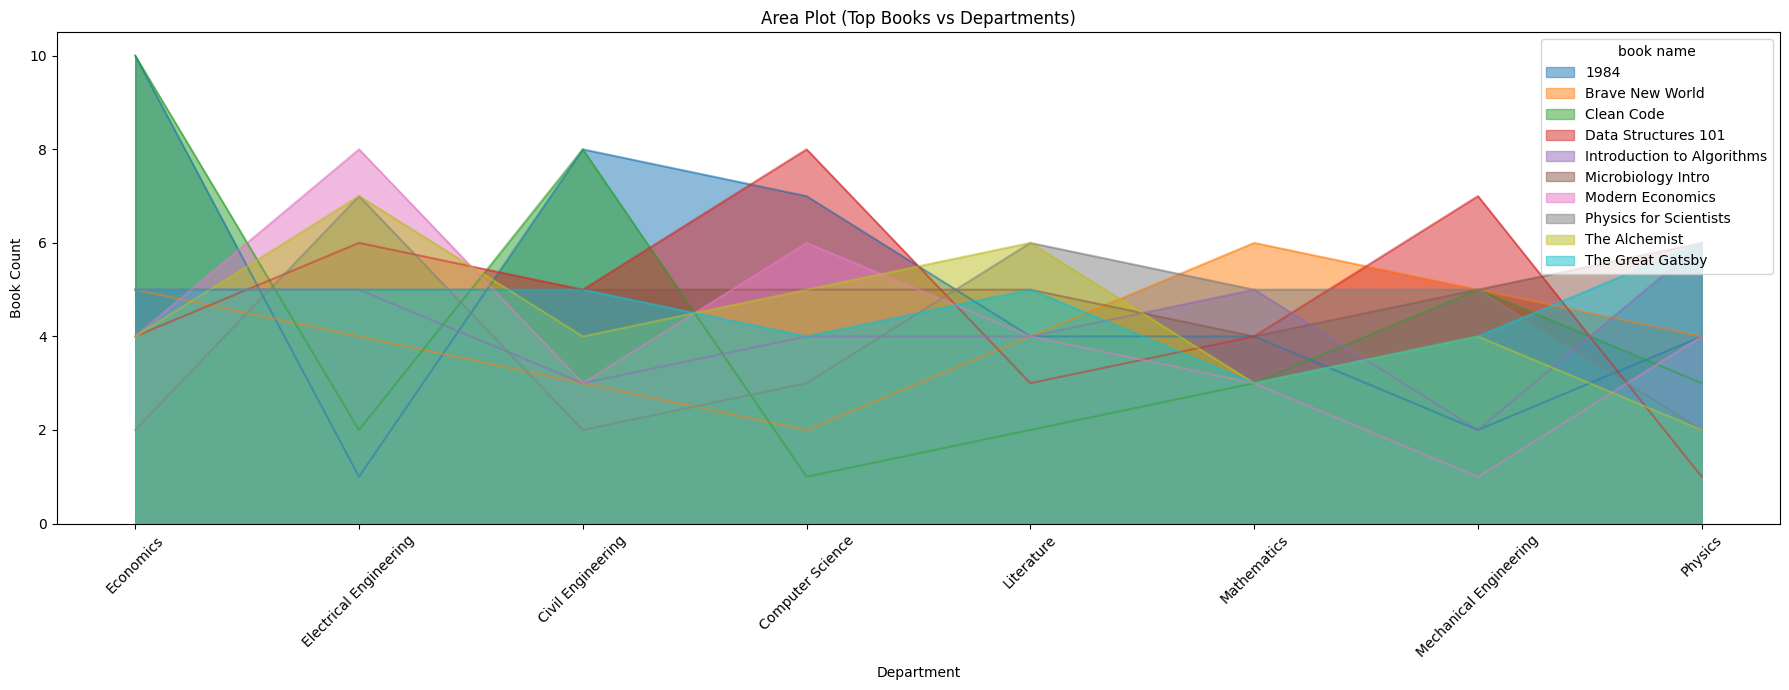

In [46]:
pivot_df_small.plot(kind='area', stacked=False, figsize=(18,7))

import matplotlib.pyplot as plt
print("===== AREA PLOT =====")
plt.xlabel("Department")
plt.ylabel("Book Count")
plt.title("Area Plot (Top Books vs Departments)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print()

===== BOX PLOT =====


<Figure size 1200x600 with 0 Axes>

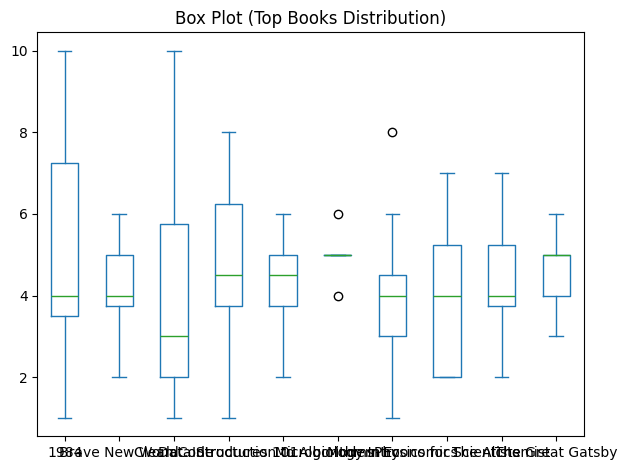

In [47]:
plt.figure(figsize=(12,6))
pivot_df_small.plot(kind='box')

print("===== BOX PLOT =====")
plt.title("Box Plot (Top Books Distribution)")
plt.tight_layout()
plt.show()
print()

===== HEATMAP =====


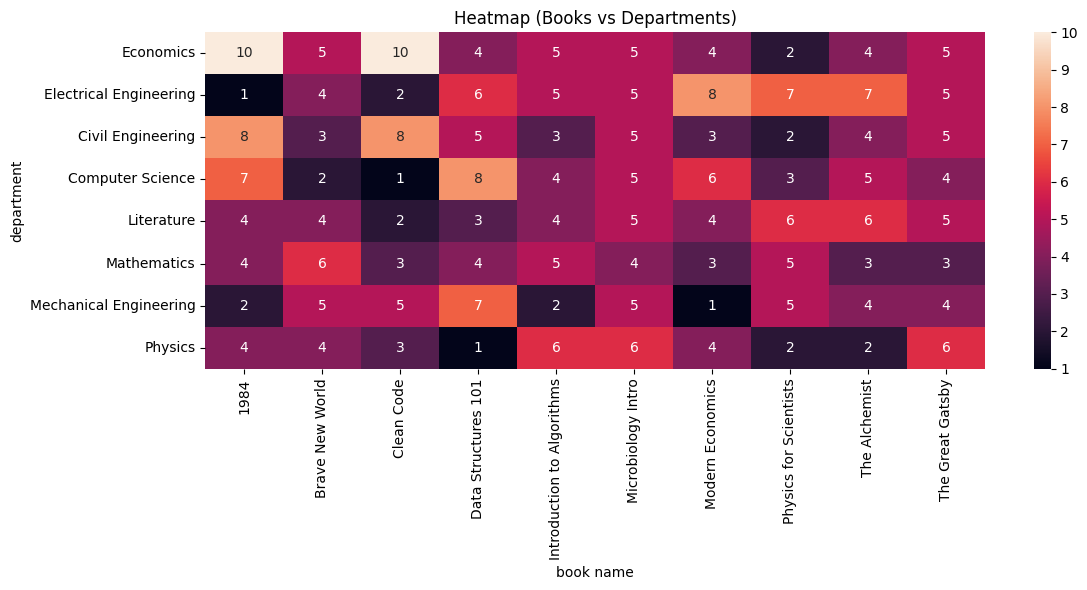

In [48]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(pivot_df_small, annot=True)

print("===== HEATMAP =====")
plt.title("Heatmap (Books vs Departments)")
plt.tight_layout()
plt.show()
print()

===== BUBBLE PLOT =====


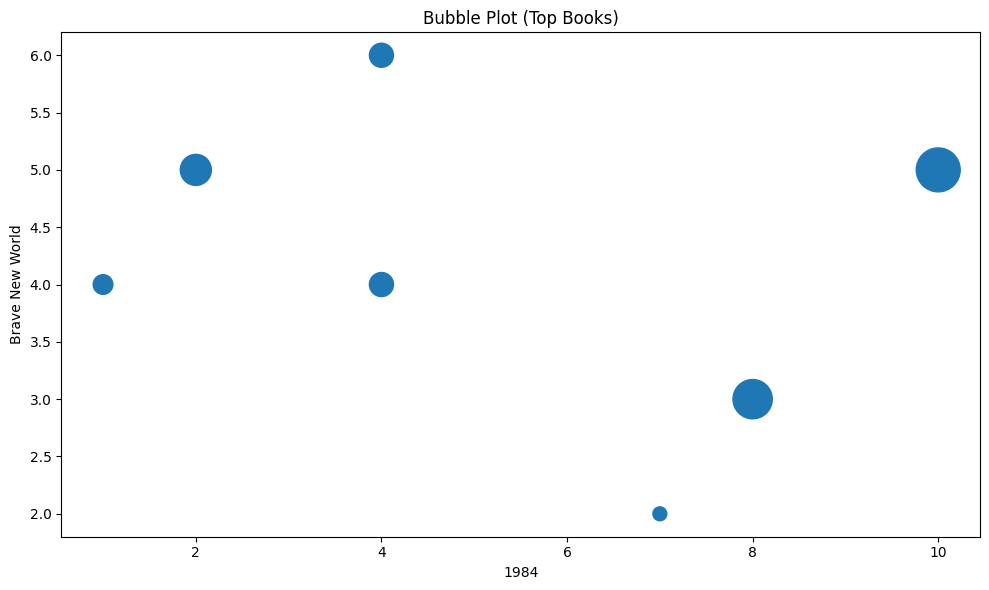

In [49]:
cols = pivot_df_small.columns

if len(cols) >= 3:
    plt.figure(figsize=(10,6))

    x = pivot_df_small[cols[0]]
    y = pivot_df_small[cols[1]]
    size = pivot_df_small[cols[2]] * 100

    plt.scatter(x, y, s=size)

    print("===== BUBBLE PLOT =====")
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.title("Bubble Plot (Top Books)")
    plt.tight_layout()
    plt.show()
    print()
else:
    print("Not enough columns for bubble plot\n")

#Experiment 18
##Real-World-and-Interactive-Visualization


In [50]:
book_col = 'book name'
dept_col = 'department'

# Top 10 books
top_books = df[book_col].value_counts().head(10).index

filtered_df = df[df[book_col].isin(top_books)]

pivot_df = filtered_df.pivot_table(index=dept_col, columns=book_col, aggfunc='size', fill_value=0)

# Reduce clutter
top_depts = pivot_df.sum(axis=1).sort_values(ascending=False).head(8).index
pivot_df_small = pivot_df.loc[top_depts]

print("===== FINAL DATA =====")
print(pivot_df_small)
print()

===== FINAL DATA =====
book name               1984  Brave New World  Clean Code  \
department                                                  
Economics                 10                5          10   
Electrical Engineering     1                4           2   
Civil Engineering          8                3           8   
Computer Science           7                2           1   
Literature                 4                4           2   
Mathematics                4                6           3   
Mechanical Engineering     2                5           5   
Physics                    4                4           3   

book name               Data Structures 101  Introduction to Algorithms  \
department                                                                
Economics                                 4                           5   
Electrical Engineering                    6                           5   
Civil Engineering                         5                       

In [51]:
import plotly.express as px

df_melt = pivot_df_small.reset_index().melt(id_vars='department', var_name='book name', value_name='count')

fig = px.treemap(df_melt,
                 path=['department', 'book name'],
                 values='count',
                 title="Treemap (Books within Departments)")

print("===== TREEMAP =====")
fig.show()
print()

===== TREEMAP =====


===== DENDROGRAM =====


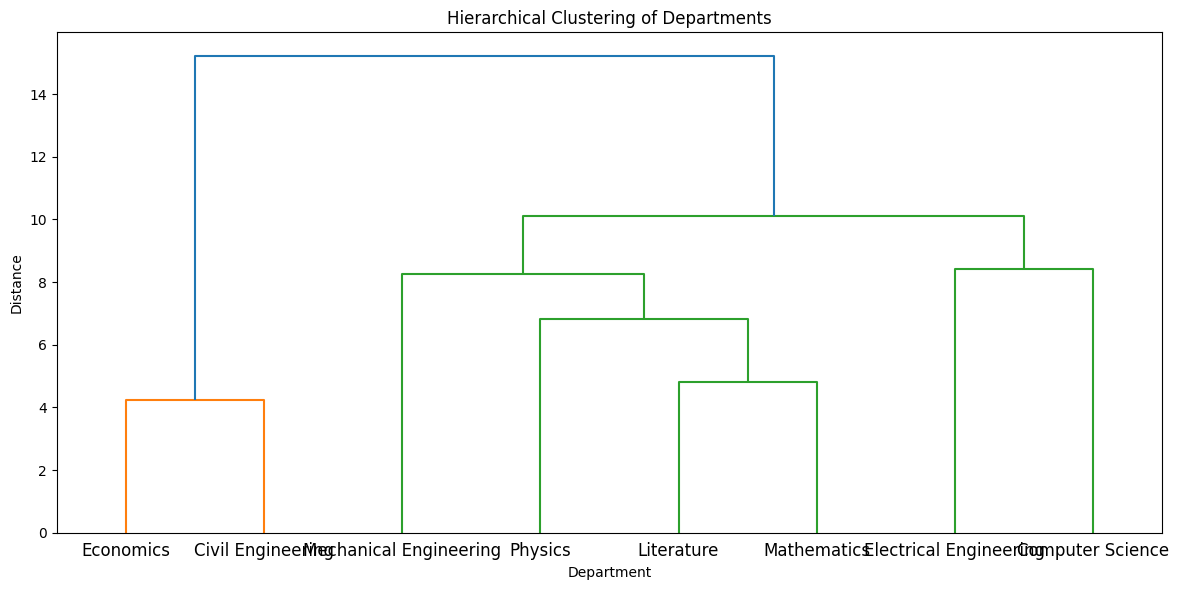

In [52]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(pivot_df_small, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, labels=pivot_df_small.index.tolist())

print("===== DENDROGRAM =====")
plt.title("Hierarchical Clustering of Departments")
plt.xlabel("Department")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()
print()

In [53]:
import plotly.graph_objects as go

labels = list(pivot_df_small.index) + list(pivot_df_small.columns)

sources = []
targets = []
values = []

for i, dept in enumerate(pivot_df_small.index):
    for j, book in enumerate(pivot_df_small.columns):
        val = pivot_df_small.iloc[i, j]
        if val > 0:
            sources.append(i)
            targets.append(len(pivot_df_small.index) + j)
            values.append(val)

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels),
    link=dict(source=sources, target=targets, value=values)
)])

print("===== SANKEY DIAGRAM =====")
fig.show()
print()

===== SANKEY DIAGRAM =====


In [54]:
cols = pivot_df_small.columns

if len(cols) >= 3:
    df_plot = pivot_df_small.reset_index()

    fig = px.scatter_3d(df_plot,
                        x=cols[0],
                        y=cols[1],
                        z=cols[2],
                        color='department',
                        title="3D Scatter Plot")

    print("===== 3D SCATTER PLOT =====")
    fig.show()
    print()
else:
    print("Not enough columns for 3D plot\n")

===== 3D SCATTER PLOT =====


In [55]:
import plotly.graph_objects as go

categories = list(pivot_df_small.columns)

dept = pivot_df_small.index[0]   # first department
values = pivot_df_small.loc[dept].values.tolist()

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=values,
    theta=categories,
    fill='toself',
    name=dept
))

fig.update_layout(title="Radar Chart (Department vs Books)")

print("===== RADAR CHART =====")
fig.show()
print()

===== RADAR CHART =====
